### Behavioral Analytics of Sports Betting Decisions

### Executive Summary

This project analyzes 1,891 real sports betting parlays from the 2025–2026 betting cycle to investigate behavioral and profitability patterns across betting activity. The analysis focuses on identifying relationships between wager timing, stake sizing, odds profiles, and betting outcomes.

Key findings include:

Higher betting activity does not necessarily correspond to stronger profitability
Overnight betting periods exhibit higher profitability variance
Larger wager sizes do not consistently improve outcomes
Wager amounts tend to increase following losses, suggesting potential recovery-driven betting behavior

These findings demonstrate how behavioral analytics can be applied to sportsbook activity to uncover patterns relevant to product analytics, risk management, and responsible gaming initiatives.

### Introduction

The objective of this analysis is to explore how behavioral betting patterns—such as wager timing, odds selection, stake sizing, and sportsbook usage—relate to profitability, volatility, and risk exposure.

Using Python, pandas, and data visualization tools, the project investigates several key questions:

- Do high-volume betting periods correspond to weaker outcomes?
- How does odds selection influence profitability and variance?
- Are larger wagers associated with stronger outcomes?
- Does losing behavior influence future wager size?

Although the dataset represents a single-user betting history, the analytical framework mirrors behavioral and product analyses commonly used in sportsbook analytics and responsible gaming research.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('transactions.csv')

In [3]:
data.head()

,bet_id,sportsbook,type,status,odds,closing_line,ev,amount,profit,time_placed,time_settled,time_placed_iso,time_settled_iso,bet_info,tags,sports,leagues
0,6a1781319afe7fcc2346d53a,Betr Picks,parlay,SETTLED_LOSS,10.0,NaN,NaN,5.0,-5.0,05/27/2026 23:41:37 GMT,05/28/2026 04:49:27 GMT,2026-05-27T23:41:37.135Z,2026-05-28T04:49:27.166Z,Over 7.5 Georgia Amoore Points WSH vs. SEA | O...,NaN,Basketball | Ice Hockey,WNBA | NHL
1,7MgpnLg,DK Pick6,round_robin_3,SETTLED_LOSS,5.0,NaN,NaN,10.0,-10.0,05/27/2026 23:00:00 GMT,05/28/2026 05:02:52 GMT,2026-05-27T23:00:00.000Z,2026-05-28T05:02:52.000Z,Under 4.5 Allisha Gray Rebounds Atlanta Dream ...,NaN,Basketball,WNBA
2,6a175f9810cd002065d04be4,Betr Picks,parlay,SETTLED_LOSS,6.0,NaN,NaN,10.0,-10.0,05/27/2026 21:18:16 GMT,05/28/2026 04:53:43 GMT,2026-05-27T21:18:16.303Z,2026-05-28T04:53:43.275Z,Over 0.5 Alex Jackson Hits + Runs + Runs Batte...,NaN,Baseball,MLB
3,6a1752edf6d6782e0ffa35bc,Betr Picks,parlay,SETTLED_LOSS,7.5,NaN,NaN,10.0,-10.0,05/27/2026 20:24:13 GMT,05/28/2026 04:53:42 GMT,2026-05-27T20:24:13.033Z,2026-05-28T04:53:42.516Z,Over 1.5 Juan Soto Hits + Runs + Runs Batted I...,NaN,Baseball | Basketball,MLB | WNBA
4,bc6c55b2-1878-49a1-ab6f-69c216b6a185,Underdog,parlay,SETTLED_LOSS,9.1,NaN,NaN,10.0,-10.0,05/27/2026 20:22:51 GMT,05/28/2026 00:25:00 GMT,2026-05-27T20:22:51.000Z,2026-05-28T00:25:00.000Z,Higher 12.5 Colton Smith Games Won O/U (vs Dan...,NaN,Tennis | Baseball | Basketball,TENNIS | MLB | WNBA


In [4]:
display(data.shape)
display(data.columns)
data['profit'].describe()

(1891, 17)

Index(['bet_id', 'sportsbook', 'type', 'status', 'odds', 'closing_line', 'ev',
       'amount', 'profit', 'time_placed', 'time_settled', 'time_placed_iso',
       'time_settled_iso', 'bet_info', 'tags', 'sports', 'leagues'],
      dtype='object')

count    1891.000000
mean        0.216864
std        19.857181
min       -54.890000
25%       -10.000000
50%        -5.000000
75%         0.000000
max       214.400000
Name: profit, dtype: float64

### The dataset contains bet-level information including odds, stake size, sportsbook, timing, and realized profit.

In [5]:
# ROI
total_profit = data['profit'].sum()
total_staked = data['amount'].sum()
roi = total_profit / total_staked
win_rate = (data['profit'] > 0).mean()
print(roi)
print(win_rate)

0.026470039586615812
0.177683765203596


### The portfolio achieved a +2.65% ROI with a 17.8% win rate, indicating a high-variance betting strategy where profitability is driven by infrequent large wins rather than consistent small gains.

In [6]:
# Profit distribution (skew check)
data['profit'].describe()

count    1891.000000
mean        0.216864
std        19.857181
min       -54.890000
25%       -10.000000
50%        -5.000000
75%         0.000000
max       214.400000
Name: profit, dtype: float64

### The median bet is negative while the mean is positive, confirming a right-skewed distribution where a small number of high-profit bets offset frequent losses.

In [7]:
data.groupby(pd.cut(data['odds'], 10), observed=True)['profit'].mean()

odds
(-0.72, 100.252]      0.221446
(100.252, 200.224]   -4.000000
(900.028, 1000.0]     0.000000
Name: profit, dtype: float64

### Profitability is not evenly distributed across odds ranges, suggesting that certain risk profiles drive most of the portfolio’s returns. Higher-odds parlays generally produced weaker and less consistent outcomes, reinforcing the high-variance nature of the betting strategy.

In [8]:
data.groupby('sportsbook')['profit'].sum().sort_values()

sportsbook
DK Pick6             -403.27
Underdog             -134.83
Chalkboard Fantasy    -69.75
Kalshi                -30.12
Fliff                 -28.92
Betr Picks             77.50
Dabble                 89.00
PrizePicks            399.02
Sleeper               511.46
Name: profit, dtype: float64

### Performance varies significantly across sportsbooks, suggesting that differences in pricing, market selection, or betting behavior may influence outcomes.

In [9]:
data.groupby(pd.cut(data['amount'], 10), observed=False).agg(
    avg_profit=('profit', 'mean'),
    count=('profit', 'count')
)

,avg_profit,count
amount,,
"(0.416, 5.912]",-0.070331,876
"(5.912, 11.354]",0.831917,845
"(11.354, 16.796]",0.278871,124
"(16.796, 22.238]",-0.891176,34
"(22.238, 27.68]",-15.172000,10
"(27.68, 33.122]",-28.940000,1
"(33.122, 38.564]",NaN,0
"(38.564, 44.006]",NaN,0
"(44.006, 49.448]",NaN,0


### Larger stakes do not necessarily correlate with stronger outcomes, suggesting that higher-confidence wagers were not consistently more profitable

In [10]:
data['time_placed_iso'] = pd.to_datetime(data['time_placed_iso'])
data['hour'] = data['time_placed_iso'].dt.hour

data.groupby('hour')['profit'].mean()

hour
0     -2.986581
1     -0.954364
2     -4.696897
3     -3.034615
4      7.547143
5     -4.151818
6     -5.200000
7    -10.000000
8     -5.000000
11    -2.500000
12     3.111667
13    -0.695238
14    -1.097449
15     3.155508
16     1.642073
17     4.011637
18     0.762019
19     0.120966
20    -0.460893
21    -2.145364
22     0.091727
23     0.649375
Name: profit, dtype: float64

### Betting performance varies by time of day, suggesting behavioral bias or informational differences across betting windows.

In [11]:
hourly_analysis = data.groupby('hour').agg(
    avg_profit=('profit', 'mean'),
    bet_count=('profit', 'size')
).reset_index()

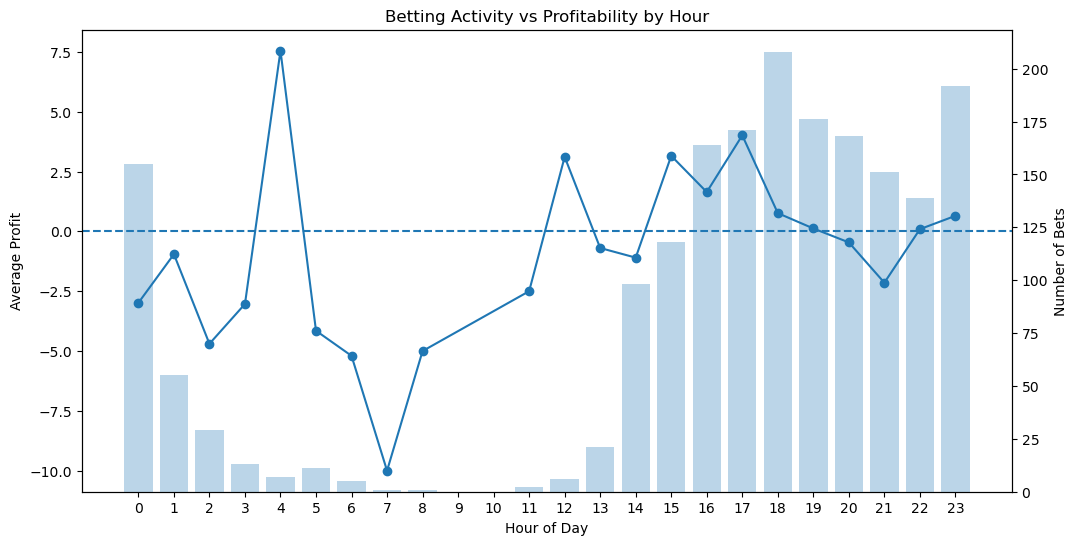

In [12]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Profit line
ax1.plot(hourly_analysis['hour'],
         hourly_analysis['avg_profit'],
         marker='o')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Average Profit')
ax1.axhline(0, linestyle='--')

# Bet count bars
ax2 = ax1.twinx()

ax2.bar(hourly_analysis['hour'],
        hourly_analysis['bet_count'],
        alpha=0.3)

ax2.set_ylabel('Number of Bets')

plt.title('Betting Activity vs Profitability by Hour')

plt.xticks(range(0,24))

plt.show()

To better understand betting behavior patterns, I analyzed betting frequency and profitability across hours of the day. Peak activity occurs during late afternoon and evening hours, likely aligning with live sporting events and increased user engagement. However, profitability during these periods remains inconsistent, suggesting that higher betting volume does not necessarily lead to stronger outcomes.

Overnight betting windows show the highest profitability variance despite lower activity levels, which may indicate more impulsive or lower-information wagering behavior.

### Does Losing Increase Future Wager Size?

To evaluate potential behavioral responses to losses, I analyzed whether wager amounts changed following losing bets. The results showed that average wager sizes increased after losses compared to after wins.

This pattern may suggest recovery-driven betting behavior, where users increase stake sizes following negative outcomes in an attempt to recover previous losses. From a behavioral analytics perspective, this type of pattern can be associated with more emotional or variance-seeking decision-making.

In [13]:
data = data.sort_values('time_placed_iso')

# previous bet result
data['previous_profit'] = data['profit'].shift(1)

# classify previous outcome
data['previous_result'] = data['previous_profit'].apply(
    lambda x: 'Loss' if x < 0 else 'Win'
)

# compare next wager sizes
next_bet_analysis = data.groupby('previous_result')['amount'].agg(
    ['mean', 'median', 'count']
)

next_bet_analysis

,mean,median,count
previous_result,,,
Loss,8.326302,10.0,1409
Win,7.802593,5.0,482


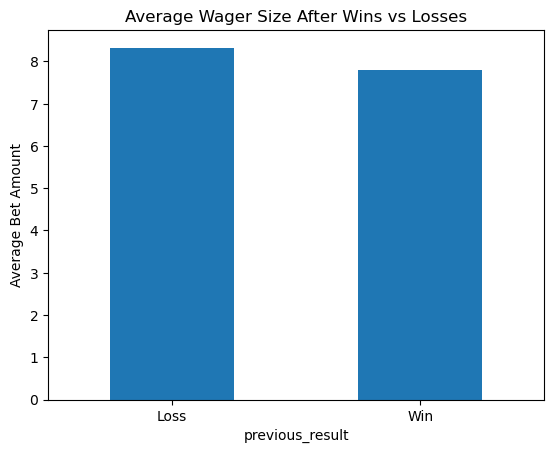

In [14]:
next_bet_analysis['mean'].plot(kind='bar')

plt.title('Average Wager Size After Wins vs Losses')
plt.ylabel('Average Bet Amount')
plt.xticks(rotation=0)
plt.show()

### How Volatile Were Betting Outcomes?

To better understand risk exposure and consistency of betting performance, I analyzed the volatility of returns across wagers. While profitability measures overall performance, volatility helps evaluate the magnitude and frequency of bankroll swings over time.

High volatility may indicate greater exposure to large gains and losses, while lower volatility may reflect more stable betting behavior and outcomes.

In [15]:
### Calculate cumulative profit
data = data.sort_values('time_placed_iso').reset_index(drop=True)

data['cumulative_profit'] = data['profit'].cumsum()

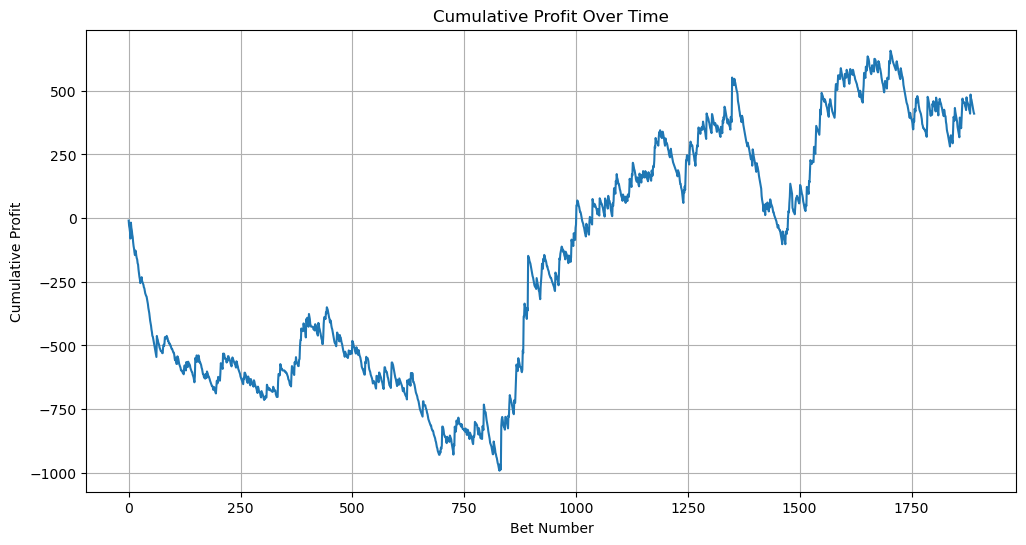

In [16]:
# Plot bankroll trajectory
plt.figure(figsize=(12,6))

plt.plot(data['cumulative_profit'])

plt.title('Cumulative Profit Over Time')
plt.xlabel('Bet Number')
plt.ylabel('Cumulative Profit')

plt.grid(True)

plt.show()

In [17]:
volatility = data['profit'].std()

avg_profit = data['profit'].mean()

print(f"Average Profit per Bet: {avg_profit:.2f}")
print(f"Profit Volatility (Std Dev): {volatility:.2f}")

Average Profit per Bet: 0.22
Profit Volatility (Std Dev): 19.86


In [18]:
data['running_max'] = data['cumulative_profit'].cummax()

data['drawdown'] = (
    data['cumulative_profit']
    - data['running_max']
)

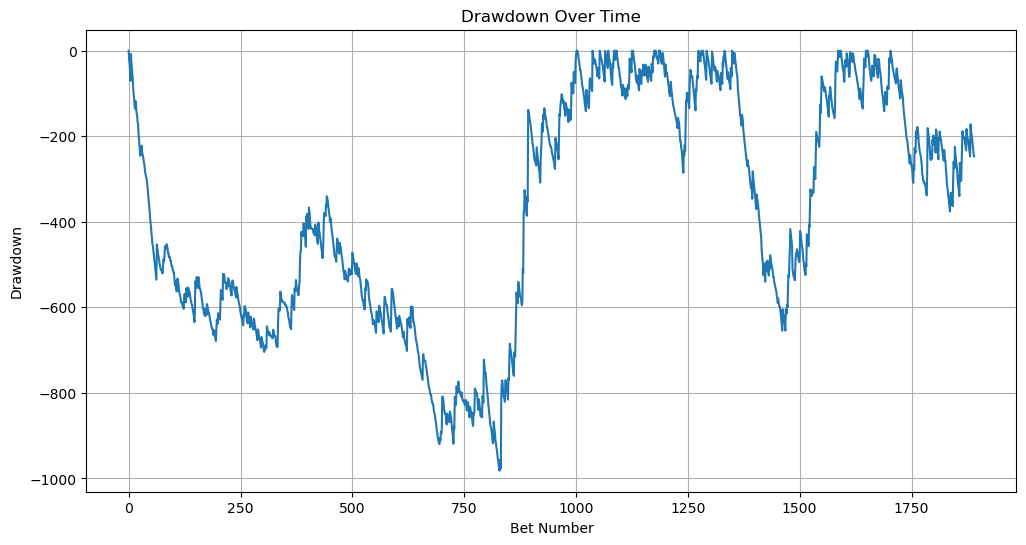

In [19]:
plt.figure(figsize=(12,6))

plt.plot(data['drawdown'])

plt.title('Drawdown Over Time')
plt.xlabel('Bet Number')
plt.ylabel('Drawdown')

plt.grid(True)

plt.show()

### Volatility and Drawdown Analysis
The cumulative profit analysis revealed significant volatility throughout the betting cycle, with extended losing stretches followed by periods of recovery and sustained gains. Drawdown analysis highlighted substantial short-term declines, suggesting that profitability was driven more by concentrated winning periods than by consistently stable outcomes.

These findings demonstrate the importance of evaluating bankroll volatility and downside risk alongside overall profitability.

### Product Implications

This analysis demonstrates how betting activity can be used to identify behavioral patterns, risk profiles, and engagement trends.

Several findings suggest potential opportunities for sportsbook product development:

High-volume betting windows did not consistently produce stronger outcomes, indicating possible impulsive or emotionally-driven betting behavior during peak engagement periods.
Higher-odds wagers generated lower win rates and higher volatility, suggesting a distinct risk-seeking user segment.
Increased wager size did not reliably correspond to improved profitability, potentially indicating inconsistent confidence calibration or reactive betting behavior.

These behavioral insights could support:

personalized betting recommendations
bankroll management tools
responsible gaming systems
user segmentation models
retention and engagement strategies

While this analysis focuses on a single-user dataset, the same framework can scale to platform-wide behavioral analytics for sportsbook products.

### Future Work
Analyze closing line value (CLV) as a proxy for predictive sharpness
Build behavioral user segments based on volatility and betting frequency
Predict profitability using timing, odds, and stake features
Explore churn/risk indicators tied to betting patterns